In [1]:
import pandas as pd
import numpy  as np 
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler 
import seaborn as sns

In [5]:
df = pd.read_excel("Q_Commerce_Data_W_O_rating_Count_1.xlsx")
df

,Brand,Quantity ( Grams),MRP,Price,Price/100 Grams,Discount (%)
0,Farmley,70.0,79,79,112.857143,0
1,Farmley,33.0,30,29,87.878788,3
2,Farmley,20.0,40,27,135.000000,32
3,Farmley,200.0,400,339,169.500000,15
4,Farmley,70.0,79,79,112.857143,0
...,...,...,...,...,...,...
443,Healthy Master,250.0,394,301,120.400000,24
444,Healthy Master,100.0,141,109,109.000000,23
445,Healthy Master,100.0,141,109,109.000000,23
446,Healthy Master,30.0,33,30,100.000000,9


In [7]:
df.columns = df.columns.str.strip()
df.columns

Index(['Brand', 'Quantity ( Grams)', 'MRP', 'Price', 'Price/100 Grams',
       'Discount (%)'],
      dtype='object')

In [8]:
features = ['Quantity ( Grams)', 'MRP','Discount (%)']

In [12]:
df_clean = df.dropna(subset=features).copy()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Brand              448 non-null    object 
 1   Quantity ( Grams)  448 non-null    float64
 2   MRP                448 non-null    int64  
 3   Price              448 non-null    int64  
 4   Price/100 Grams    448 non-null    float64
 5   Discount (%)       448 non-null    int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 21.1+ KB


In [15]:
X = df_clean[features]
X_scaled = StandardScaler().fit_transform(X)
X_scaled

array([[-0.57305375, -0.42960917, -1.47515837],
       [-0.70918753, -0.48197331, -1.27053325],
       [-0.75701832, -0.47128675,  0.70750965],
       ...,
       [-0.462675  , -0.36335251,  0.09363427],
       [-0.7202254 , -0.47876734, -0.86128299],
       [-0.462675  , -0.36335251,  0.09363427]], shape=(448, 3))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

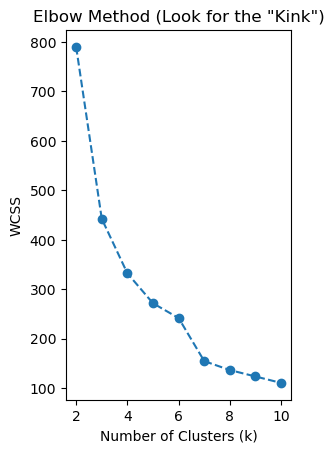

In [22]:
K_range = range(2,11)
wcss = []
for K in K_range:
    k_means = KMeans(n_clusters=K,random_state=42)
    k_means.fit(X_scaled)
    wcss.append(k_means.inertia_)

plt.subplot(1,2,1)
plt.plot(list(K_range),wcss,marker="o",linestyle="--")
plt.title('Elbow Method (Look for the "Kink")')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

In [24]:
silhouette_scores = {}
score = silhouette_score(X_scaled,k_means.labels_)
silhouette_scores[K] = score 
score

0.3682711599597518

In [27]:
optimal_k = max(silhouette_scores,key=silhouette_scores.get)
optimal_k

10

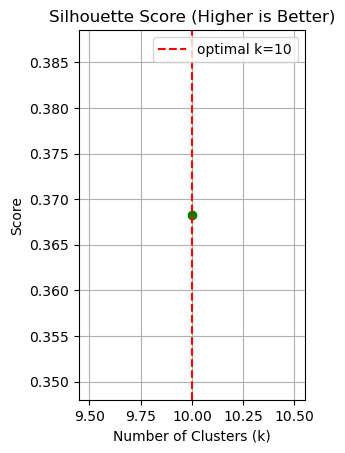

In [31]:
plt.subplot(1, 2, 2)
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o', color='green', linestyle='--')
plt.title('Silhouette Score (Higher is Better)')
plt.xlabel('Number of Clusters (k)')
plt.axvline(x=optimal_k,color="red",linestyle="--",label=f"optimal k={optimal_k}")
plt.ylabel('Score')
plt.legend()
plt.grid(True)

In [30]:
silhouette_scores

{10: 0.3682711599597518}

In [36]:
final_clustering = KMeans(n_clusters=optimal_k,random_state=42)
df_clean["Cluster"] = final_clustering.fit_predict(X_scaled)



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [40]:
df_clean = df_clean.drop(["clusters"],axis=1)

In [43]:
df_clean
df_clean.to_excel("clustering_4.xlsx",index=False)

In [ ]:
df.